# Posterior for local recombination rate using SBI (old summary stats)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

Load genome data and clonal tree.

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(30, 1000000)

In [4]:
np.random.seed(100)
clonal_tree = ClonalTree(n=30)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                    ____ 14
                                                                   |
                                                                   |    , 15
                                                        ___________|   _|
                                                       |           |  | , 5
                                                       |           |  | |
                                                       |           |__| | 24
                                                       |              |
                                                       |              | , 27
                                                       |              |_|
                                                       |                | 4
                                                       |
                                                       |      __________ 18
                                             

## Summary statistics

### Get summary statistics from SimBac data

In [5]:
x_500_SB = np.loadtxt("../data/x_500_SB.csv", delimiter=",")
x_2000_SB = np.loadtxt("../data/x_2000_SB.csv", delimiter=",")
x_6000_SB = np.loadtxt("../data/x_6000_SB.csv", delimiter=",")

x_500_SB.shape, x_2000_SB.shape, x_6000_SB.shape

((100, 46), (100, 46), (100, 46))

### Load simulations from ClonalOrigin model

In [6]:
x_500_CO = np.loadtxt("../data/x_500_CO.csv", delimiter=",")
x_2000_CO = np.loadtxt("../data/x_2000_CO.csv", delimiter=",")
x_6000_CO = np.loadtxt("../data/x_6000_CO.csv", delimiter=",")

x_500_CO.shape, x_2000_CO.shape, x_6000_CO.shape

((100, 46), (100, 46), (100, 46))

In [7]:
theta1 = np.loadtxt('../data/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/x2.csv', delimiter=",")

x = np.vstack([x1, x2])
theta = np.vstack([theta1, theta2])

print(theta.shape, x.shape)

(20000, 2) (20000, 46)


In [8]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

## NPE

### Create prior to pass range knowledge to NPE

In [9]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

### Using simulation of exact LD and G4 counts + HI + S + L

In [10]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference1 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [11]:
exact_col = list(range(0, 8)) + list(range(16, 24)) + [32, 33, 45]
x1 = x[:, exact_col]

x1.shape, x1.dtype

(torch.Size([20000, 19]), torch.float32)

In [12]:
density_estimator1 = inference1.append_simulations(theta, x1).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior1 = inference1.build_posterior(density_estimator1)

 Neural network successfully converged after 181 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-04T11_30_37.973265' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


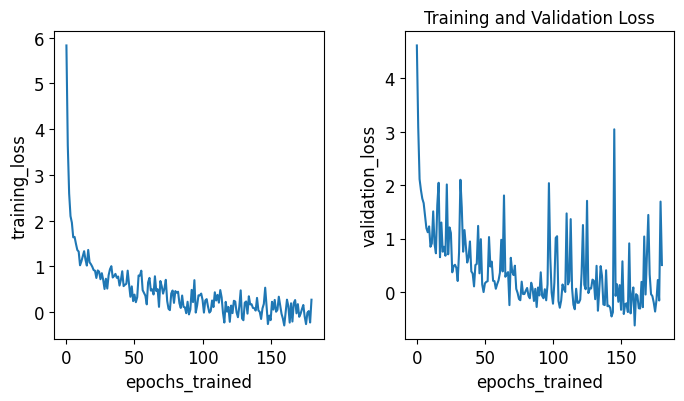

In [13]:
fig, axes = plot_summary(
    inference1, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [14]:
theta1_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta1_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta1_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta1_500.shape, theta1_2000.shape, theta1_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [16]:
for i in range(100):
    x_obs = torch.tensor(x_500_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_500[i, :, :] = theta_post.cpu().numpy()

In [17]:
for i in range(100):
    x_obs = torch.tensor(x_2000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_2000[i, :, :] = theta_post.cpu().numpy()

In [18]:
for i in range(100):
    x_obs = torch.tensor(x_6000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_6000[i, :, :] = theta_post.cpu().numpy()

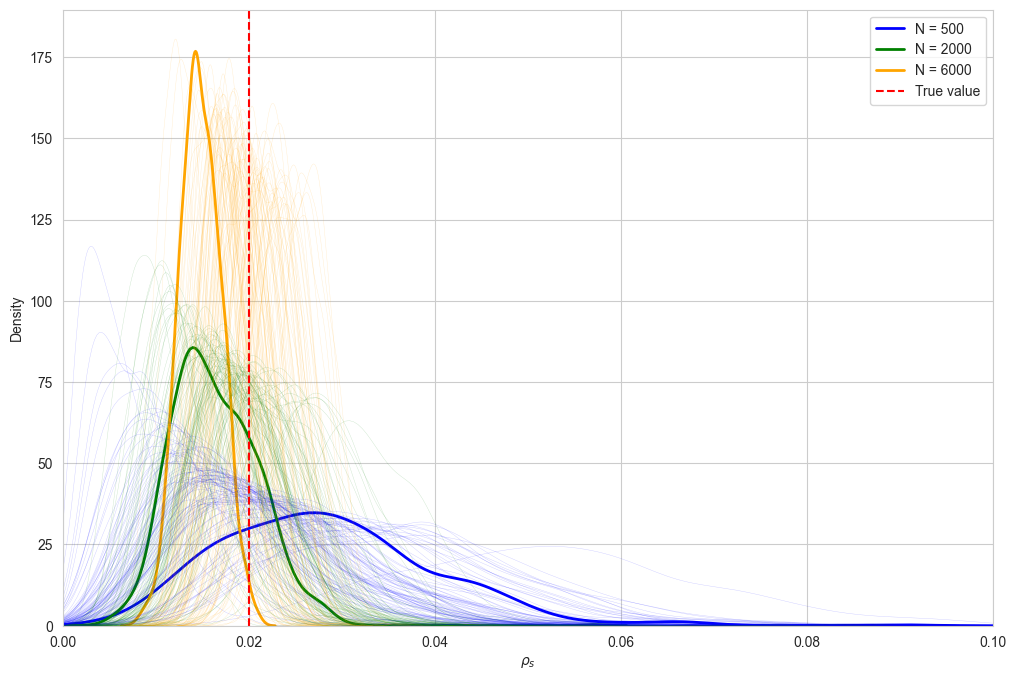

In [19]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

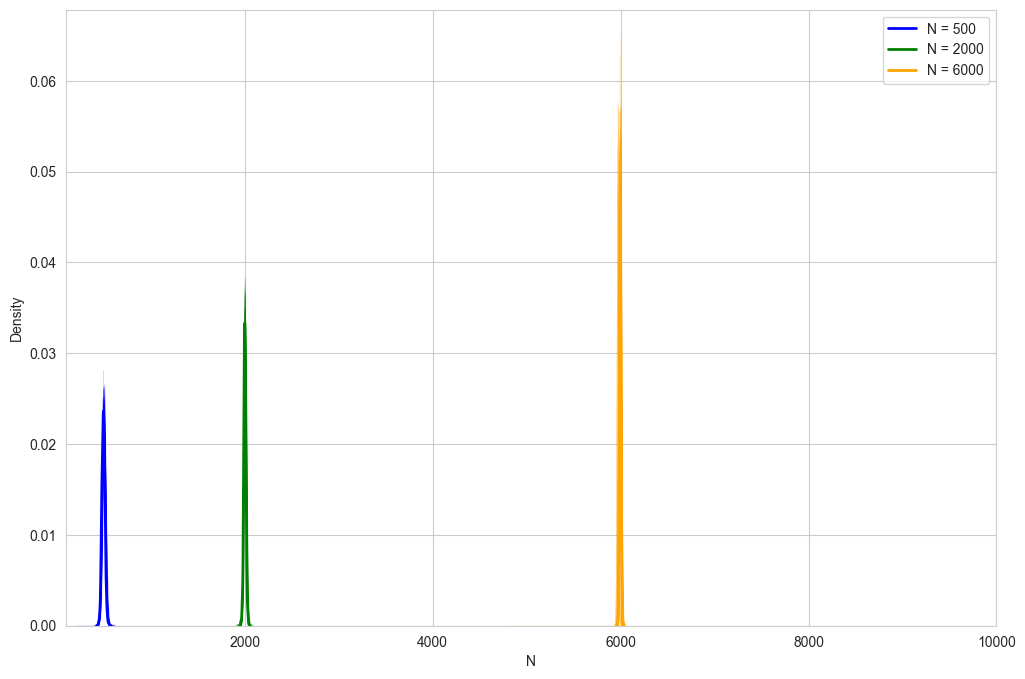

In [20]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

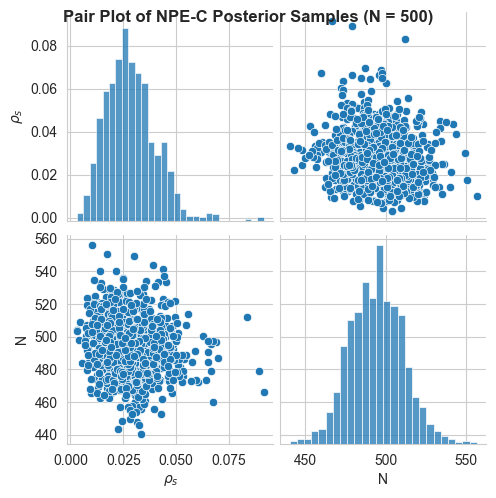

In [21]:
df_500 = pd.DataFrame(theta1_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

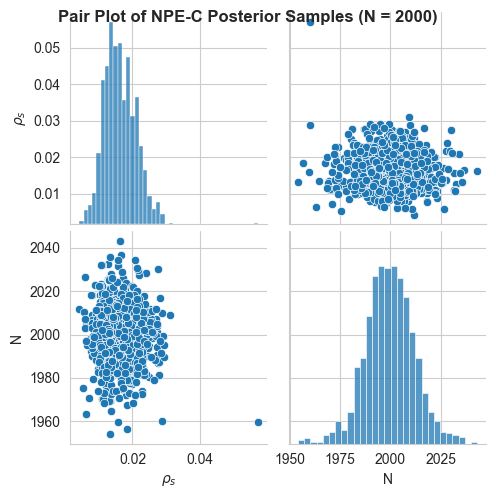

In [22]:
df_2000 = pd.DataFrame(theta1_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

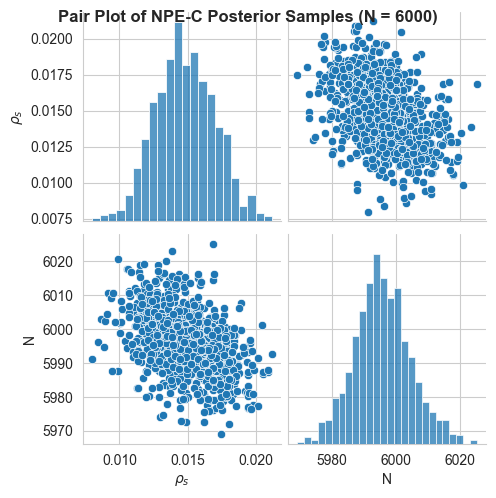

In [23]:
df_6000 = pd.DataFrame(theta1_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [24]:
theta1_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta1_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta1_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta1_500_CO.shape, theta1_2000_CO.shape, theta1_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [25]:
for i in range(100):
    x_obs = torch.tensor(x_500_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_500_CO[i, :, :] = theta_post.cpu().numpy()

In [26]:
for i in range(100):
    x_obs = torch.tensor(x_2000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [27]:
for i in range(100):
    x_obs = torch.tensor(x_6000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_6000_CO[i, :, :] = theta_post.cpu().numpy()

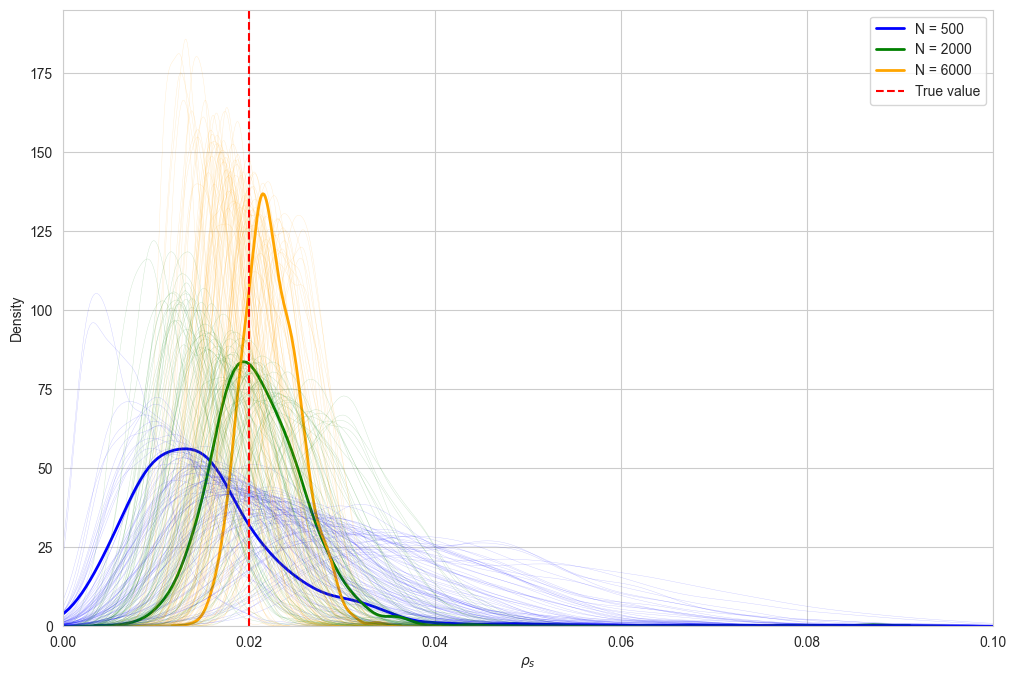

In [28]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

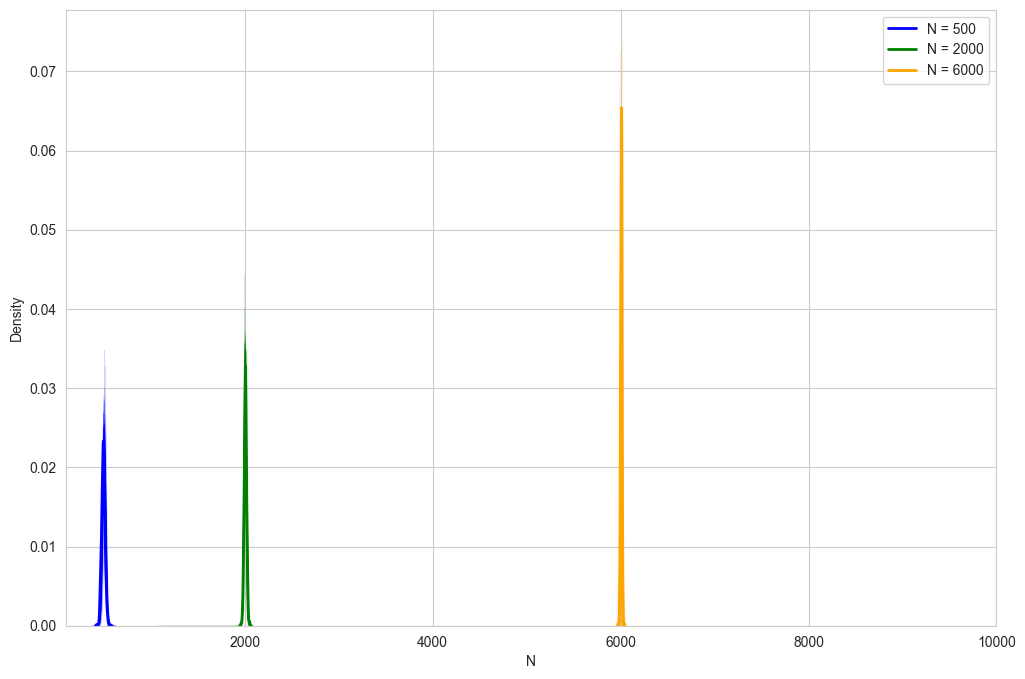

In [29]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

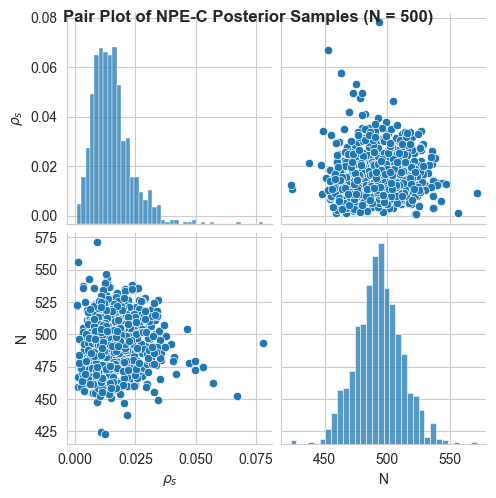

In [30]:
df_500 = pd.DataFrame(theta1_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

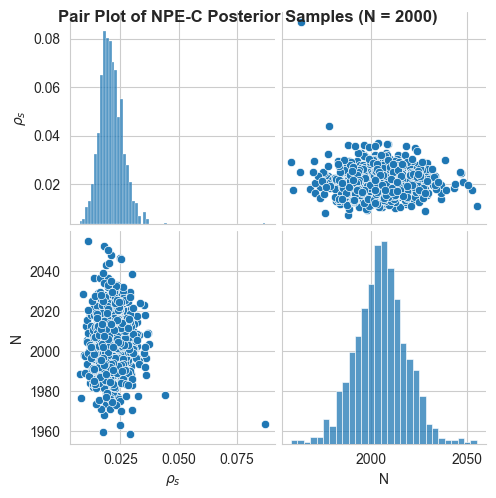

In [31]:
df_2000 = pd.DataFrame(theta1_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

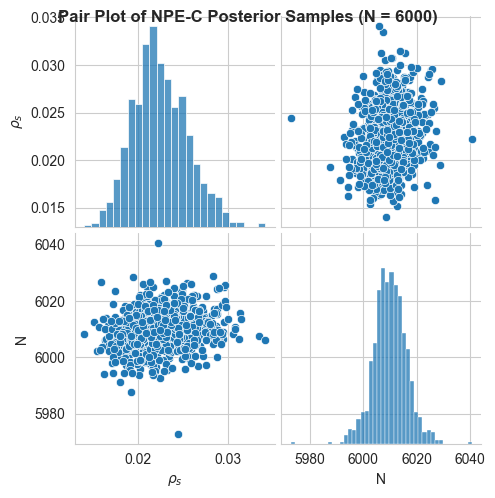

In [32]:
df_6000 = pd.DataFrame(theta1_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

### Using simulation of proportion values + HI + S + L

In [33]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference2 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [34]:
prop_col = list(range(8, 16)) + list(range(24, 32)) + [32, 33, 45]
x2 = x[:, prop_col]

x2.shape, x2.dtype

(torch.Size([20000, 19]), torch.float32)

In [35]:
density_estimator2 = inference2.append_simulations(theta, x2).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior2 = inference2.build_posterior(density_estimator2)

 Neural network successfully converged after 104 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-04T11_42_30.248061' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


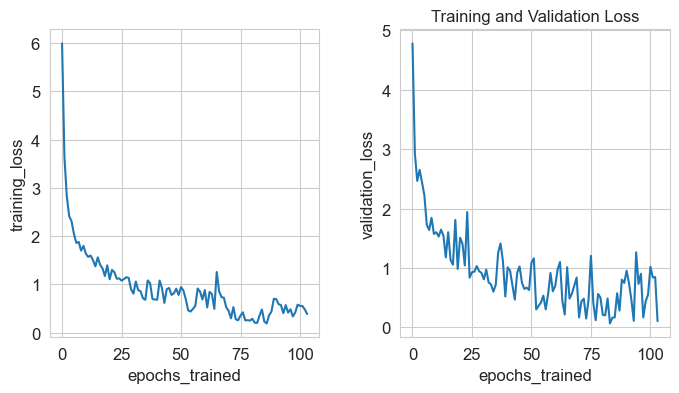

In [36]:
fig, axes = plot_summary(
    inference2, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [37]:
theta2_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta2_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta2_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta2_500.shape, theta2_2000.shape, theta2_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [38]:
for i in range(100):
    x_obs = torch.tensor(x_500_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_500[i, :, :] = theta_post.cpu().numpy()

In [39]:
for i in range(100):
    x_obs = torch.tensor(x_2000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_2000[i, :, :] = theta_post.cpu().numpy()

In [40]:
for i in range(100):
    x_obs = torch.tensor(x_6000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_6000[i, :, :] = theta_post.cpu().numpy()

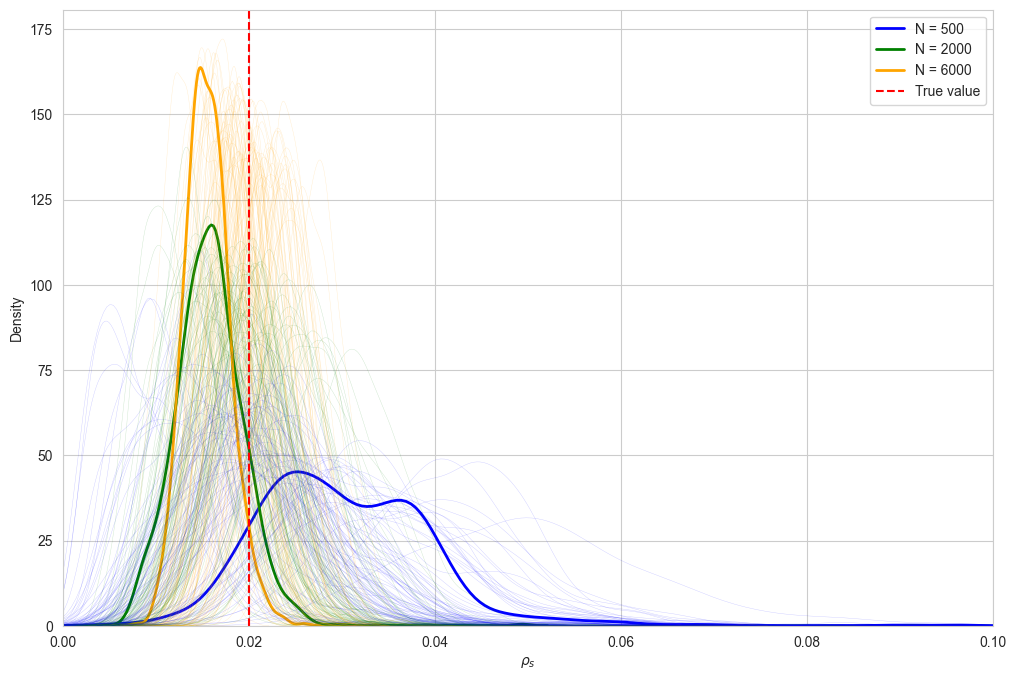

In [41]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

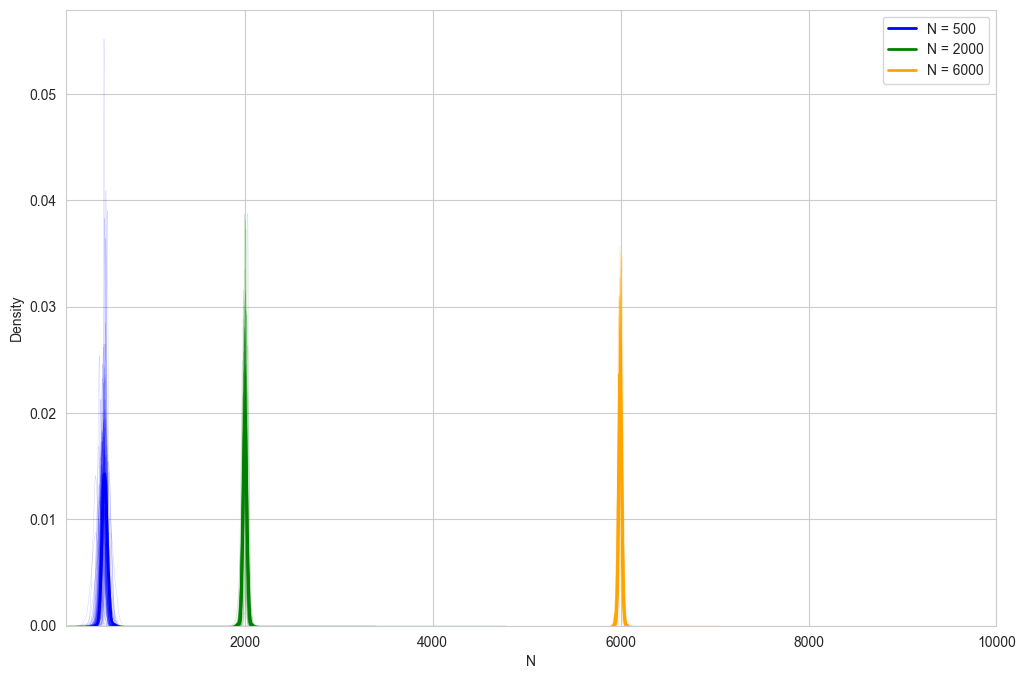

In [42]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

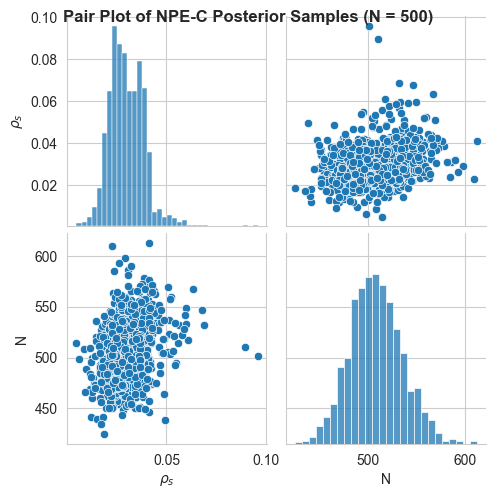

In [43]:
df_500 = pd.DataFrame(theta2_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

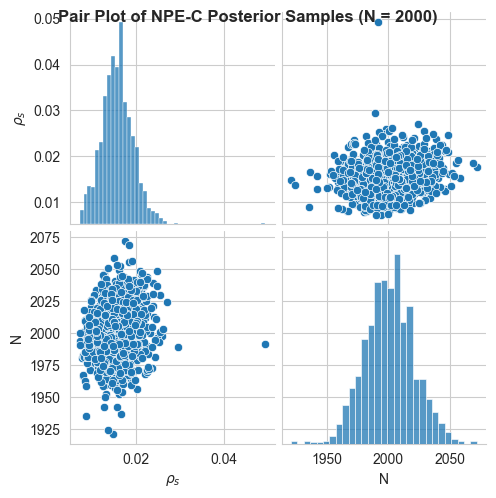

In [44]:
df_2000 = pd.DataFrame(theta2_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

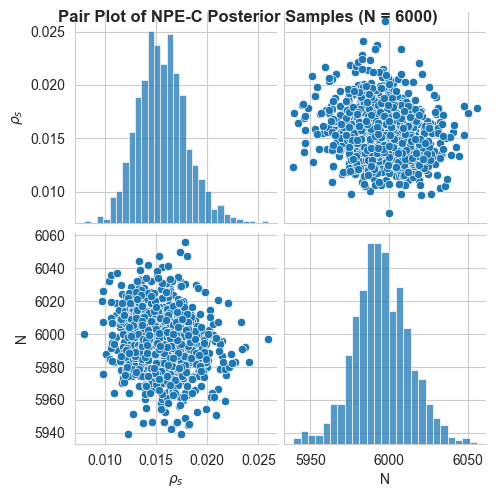

In [45]:
df_6000 = pd.DataFrame(theta2_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [46]:
theta2_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta2_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta2_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta2_500_CO.shape, theta2_2000_CO.shape, theta2_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [47]:
for i in range(100):
    x_obs = torch.tensor(x_500_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_500_CO[i, :, :] = theta_post.cpu().numpy()

In [48]:
for i in range(100):
    x_obs = torch.tensor(x_2000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [49]:
for i in range(100):
    x_obs = torch.tensor(x_6000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_6000_CO[i, :, :] = theta_post.cpu().numpy()

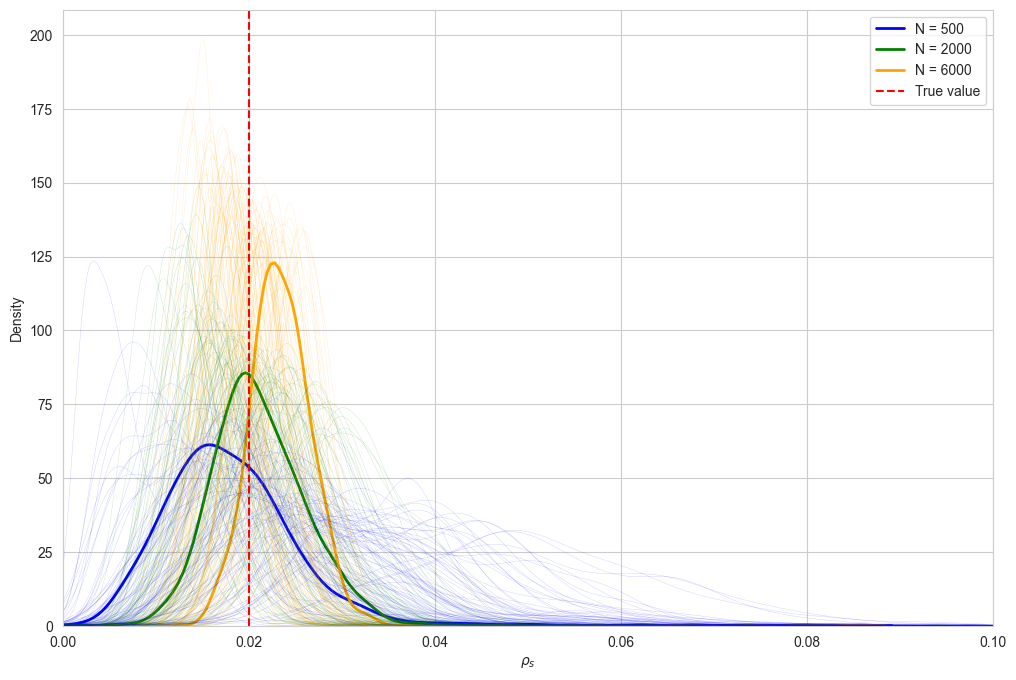

In [50]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

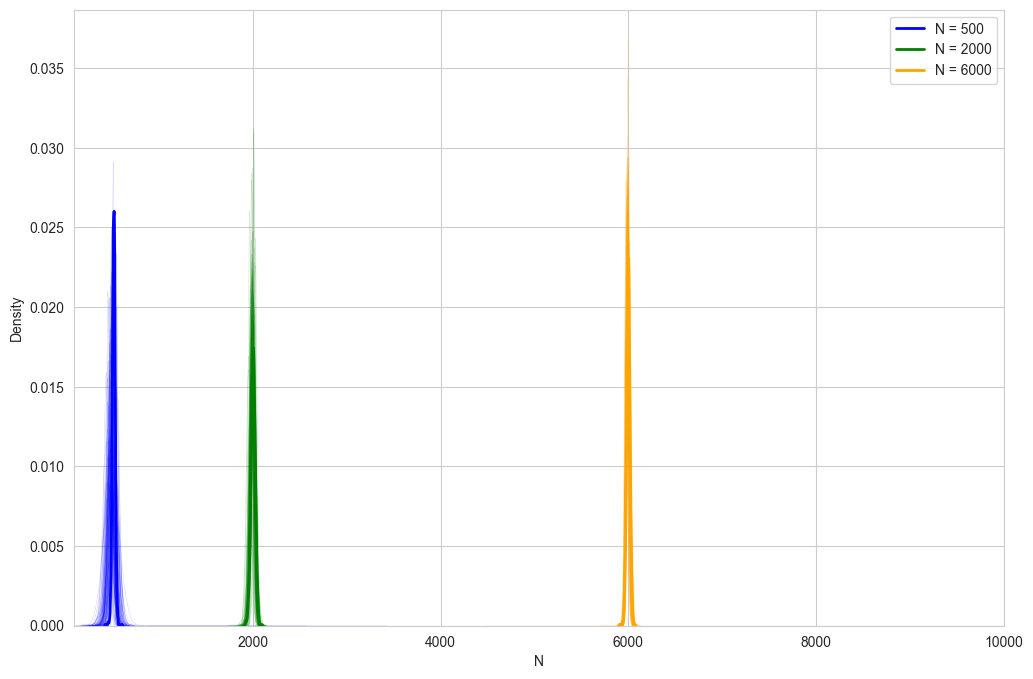

In [51]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

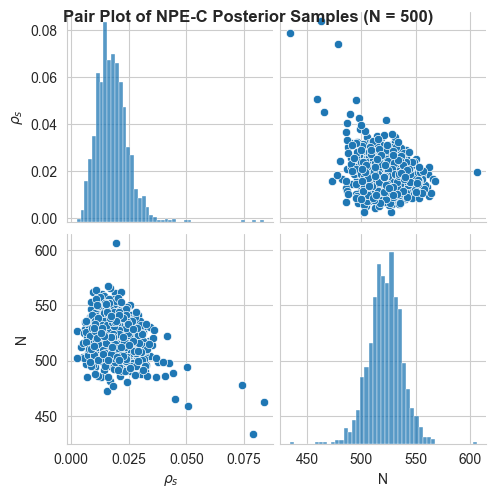

In [52]:
df_500 = pd.DataFrame(theta2_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

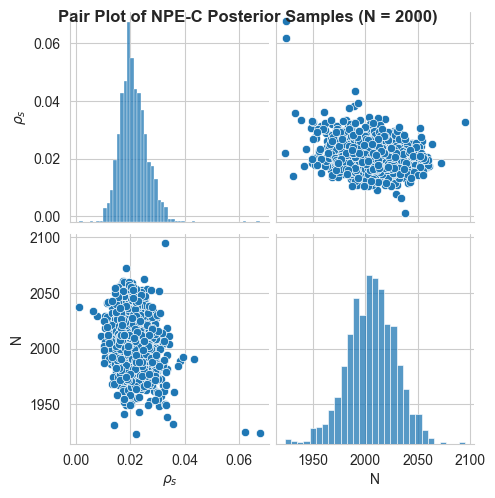

In [53]:
df_2000 = pd.DataFrame(theta2_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

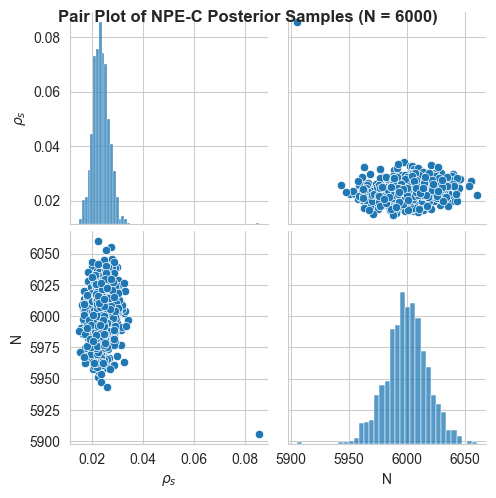

In [54]:
df_6000 = pd.DataFrame(theta2_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

### Only HI, S and L

In [55]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference3 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [56]:
all_col = [32, 33, 45]
x3 = x[:, all_col]

x3.shape, x3.dtype

(torch.Size([20000, 3]), torch.float32)

In [57]:
density_estimator3 = inference3.append_simulations(theta, x3).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior3 = inference3.build_posterior(density_estimator3)

 Neural network successfully converged after 110 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-04T11_50_23.489359' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


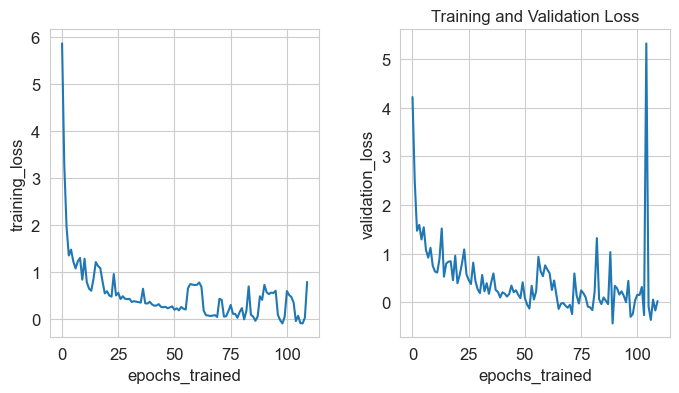

In [58]:
fig, axes = plot_summary(
    inference3, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [59]:
theta3_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta3_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta3_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta3_500.shape, theta3_2000.shape, theta3_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [60]:
for i in range(100):
    x_obs = torch.tensor(x_500_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_500[i, :, :] = theta_post.cpu().numpy()

In [61]:
for i in range(100):
    x_obs = torch.tensor(x_2000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_2000[i, :, :] = theta_post.cpu().numpy()

In [62]:
for i in range(100):
    x_obs = torch.tensor(x_6000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_6000[i, :, :] = theta_post.cpu().numpy()

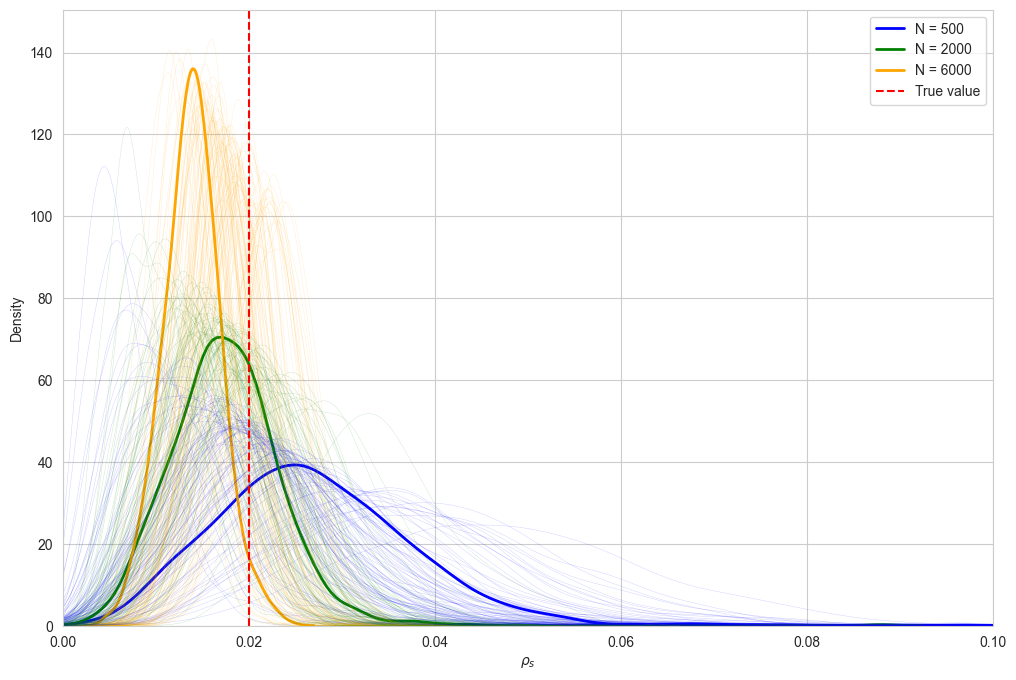

In [63]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

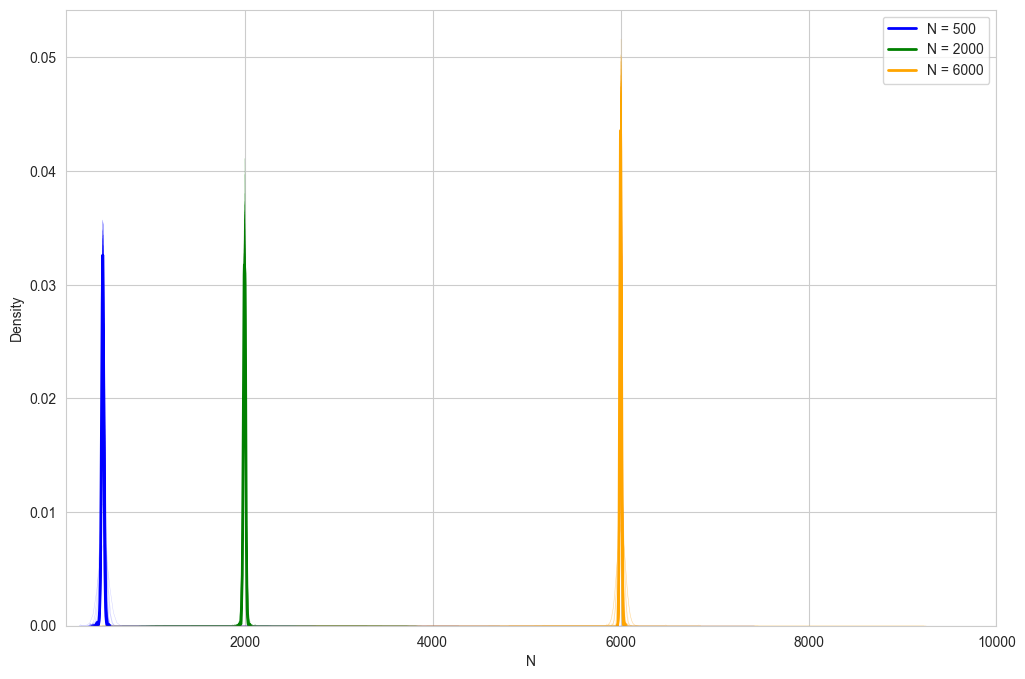

In [64]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

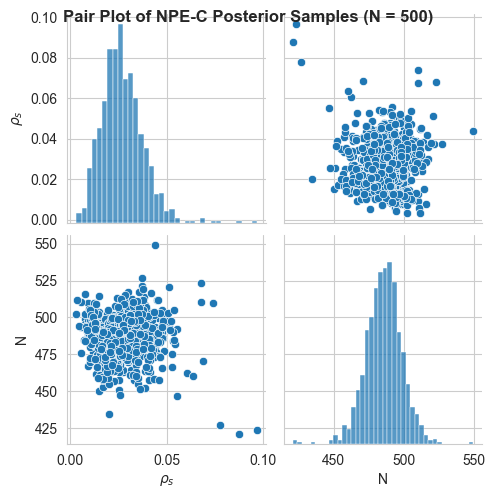

In [65]:
df_500 = pd.DataFrame(theta3_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

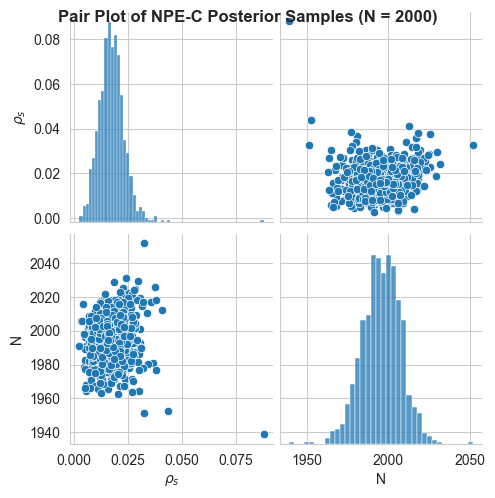

In [66]:
df_2000 = pd.DataFrame(theta3_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

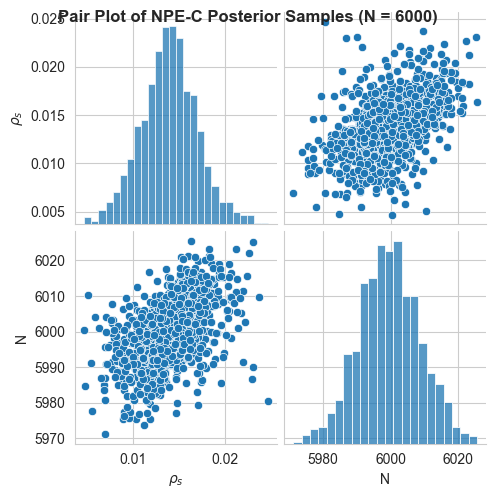

In [67]:
df_6000 = pd.DataFrame(theta3_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [68]:
theta3_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta3_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta3_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta3_500_CO.shape, theta3_2000_CO.shape, theta3_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [69]:
for i in range(100):
    x_obs = torch.tensor(x_500_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_500_CO[i, :, :] = theta_post.cpu().numpy()

In [70]:
for i in range(100):
    x_obs = torch.tensor(x_2000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [71]:
for i in range(100):
    x_obs = torch.tensor(x_6000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_6000_CO[i, :, :] = theta_post.cpu().numpy()

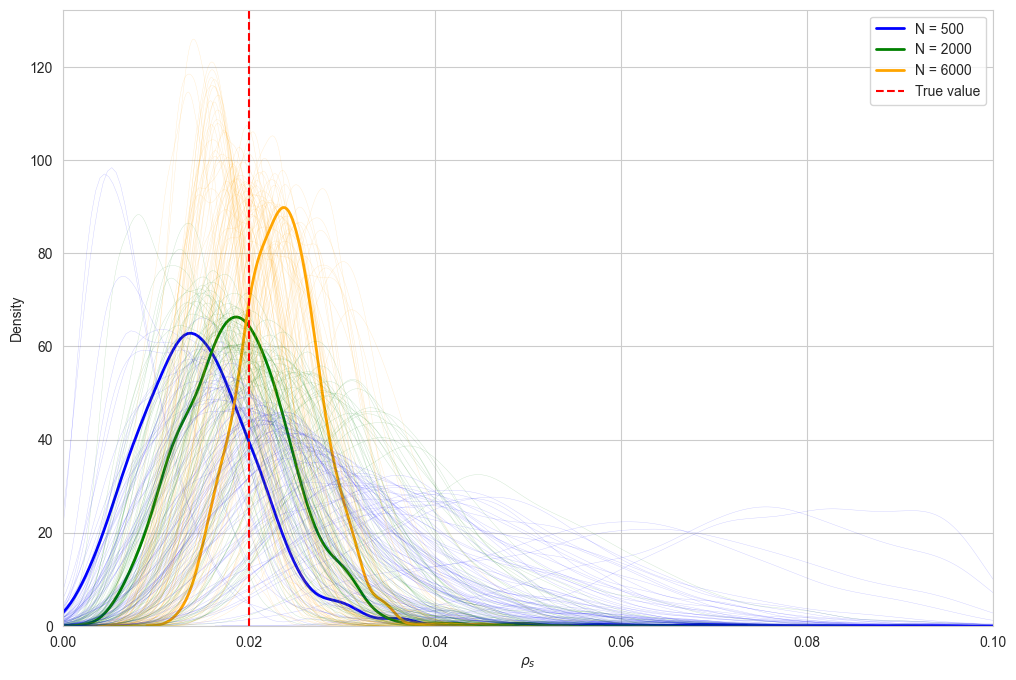

In [72]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

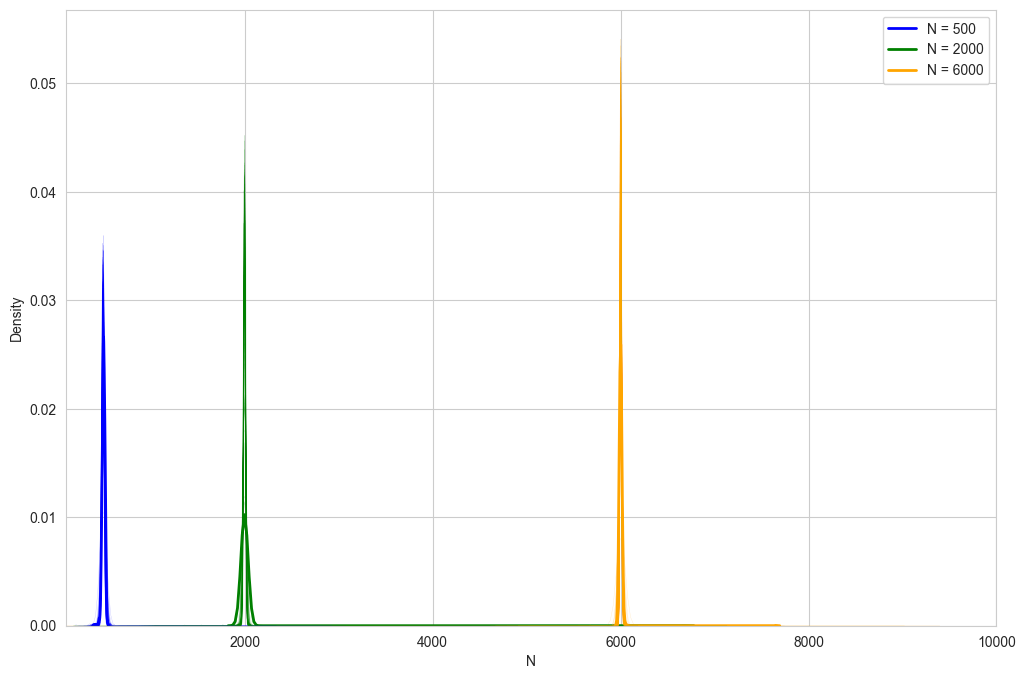

In [73]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

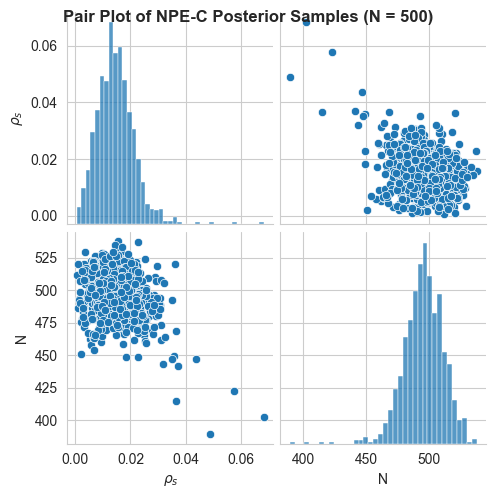

In [74]:
df_500 = pd.DataFrame(theta3_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

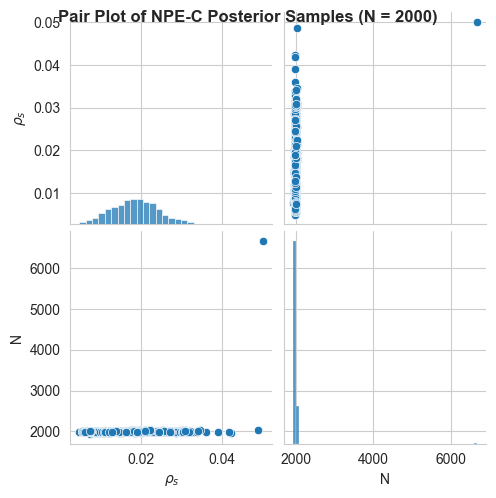

In [75]:
df_2000 = pd.DataFrame(theta3_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

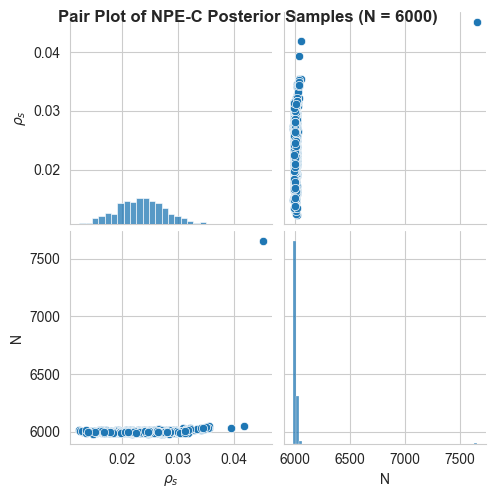

In [76]:
df_6000 = pd.DataFrame(theta3_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()